<a href="https://colab.research.google.com/github/TejasDharmale/Bayesian-machine-learning-assignment/blob/main/Tejas_Dharmale_assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bayesian Machine Learning
# Assignment 1: Markov Chain Monte Carlo (MCMC)

    Name: Tejas Dharmale
    Student #: s1190137

In [3]:
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import jax.random as jr
from jax.scipy.stats import multivariate_normal
from jax.scipy.special import logsumexp
from functools import partial

## Optimization vs. marginalization

A key difference between Bayesian methods and optimization-based approaches is in the treatment of uncertainty. Optimization techniques aim to find a single "best" point estimate, such as the maximum of a probability distribution.
Bayesian approaches, on the other hand, infer the uncertainty through a process called marginalization. This involves integrating over all possibilities to account for uncertainty, weighting each potential solution by its probability. This provides a more complete and robust understanding of the problem, especially when the probability landscape is complex or has multiple peaks (i.e., is multimodal).

In this assignment, you will explore these two approaches. First, we start with considering the case of optimization, by implementing a basic gradient ascent algorithm on the log probability density function.

## 1.1 The Triple banana density (0.5 point)

Throughout this notebook, we will consider the running example density from the lectures: the triple banana density, which is defined as:

$$p(x) = \sum^K_{k=1} \frac{1}{K}\: \mathcal{N}\left(\boldsymbol{x}\mid \begin{bmatrix}\mu_k \\ b_k(x_1 - \mu_k)^2 +c_k  \end{bmatrix} , \Sigma\right)$$
with
$\Sigma = \begin{pmatrix} \sqrt{8} & 0 \\
                         0 & 1
            \end{pmatrix},$ and $k=3, a=(0,0,0)^{\top}, b=(1, -1, 1)^{\top},  c=(0, 5, -5)^{\top}$, and $\mu_k = (-6, 0, 6)^{\top}$

This log density is already implemented below, along with a visualization function. Run the given functions, then answer:


(a) What parameter of the density model is responsible for the distances horizontal distances between the Gaussian components?

(b) Where is the input with the largest probability density?

In [4]:
def log_target_dist(x):
    """
    Calculates the log probability of the banana-shaped mixture distribution.

    Args:
        x: (2,)
    Returns:
        The log probability of x.
    """
    K = 3
    mu_k = jnp.array([-6, 0.0, 6])
    cov = jnp.array([[jnp.sqrt(8.0), 0.0],
                     [0.0, 1.0]])
    b_values = jnp.array([1., -1., 1.])
    c_values = jnp.array([.0, 5.0, -5.0])
    y_means = c_values + b_values * (x[0] - mu_k)**2
    means = jnp.stack([mu_k, y_means], axis=-1)
    log_pdfs = multivariate_normal.logpdf(x, mean=means, cov=cov)
    return logsumexp(log_pdfs) - jnp.log(K)


In [5]:
def visualize_density(log_prob_fn):
    """
    Creates a contour plot of the given 2D log probability function.
    """
    x1_range, x2_range = jnp.linspace(-25, 25, 200), jnp.linspace(-15, 15, 200)
    x1_grid, x2_grid = jnp.meshgrid(x1_range, x2_range)
    xy_grid = jnp.stack([x1_grid, x2_grid], axis=-1)
    eval_on_grid = jax.vmap(jax.vmap(log_prob_fn, in_axes=0), in_axes=0)
    Z_log = eval_on_grid(xy_grid)
    Z = jnp.exp(Z_log)

    # Visualize
    plt.figure(figsize=(10, 4))
    contour = plt.contourf(x1_grid, x2_grid, Z, cmap='cividis')
    plt.title("Contour Plot of the Three Banana Density")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.colorbar(contour, label="Probability Density")


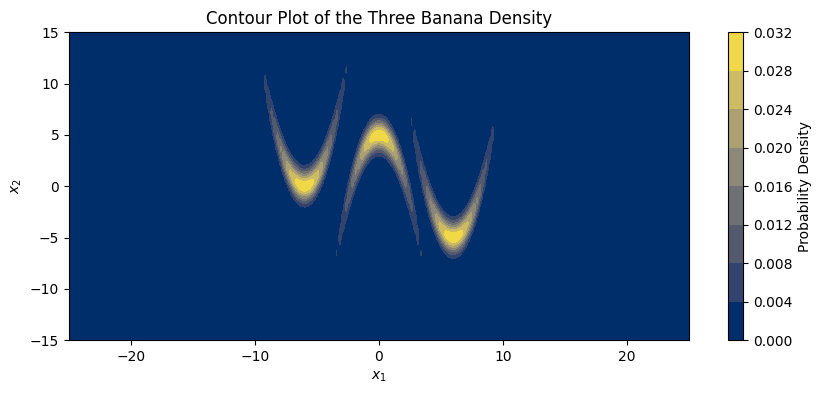

In [6]:
visualize_density(log_target_dist)

In [7]:
#1a
mu_k = jnp.array([-6.0, 0.0, 6.0])
print("H centers (mu_k):", mu_k)   #horizontal center
print("Distances between components:", jnp.diff(mu_k))

H centers (mu_k): [-6.  0.  6.]
Distances between components: [6. 6.]


The horizontal distances are controlled by the mean vector μ k = (-6, 0, 6), since each components x1 center is exactly μ k. The components are spaced 6 units apart.

In [8]:
#1b
candidates = jnp.array([[-6., 0.], [0., 5.], [6., -5.]])
for c in candidates:
    print(c, jnp.exp(log_target_dist(c)))

[-6.  0.] 0.031544697
[0. 5.] 0.031544697
[ 6. -5.] 0.031544697


In [36]:
# Explaination to Question 1b] Based on my understanding, each banana peaks at its center (μ_k, c_k),
# so the three centers are (-6, 0), (0, 5) and (6, -5). When we evaluate the density at these points
# all three give the same value (about 0.0315). So there is no single largest input: the density has
# three equal maxima, one at each banana center. This is because the bananas are spaced far enough
# apart that each center is dominated by its own component, so they all reach the same peak height.

# 1.2 An optimization-based approach (1 points)
Write a basic local optimization loop that aims to maximize the probability density in the landscape, by choosing a gradient-based optimization method of choice (e.g., gradient ascent), a sensible initial condition and lastly an appropriate step size (or learning rate).

Apply the chosen update rule for $n$ iterations, and visualize the resulting trajectory of intermediate optimization steps in red on top of the contour visualization given above.

(c) Comment in your answer on the convergence of the resulting trajectories. Is the method able to recover the optima? How much information multi-modal nature of the banana density can we capture via the chosen optimization algorithm?

Note: correct code without verbal explanations can obtain at most half of the maximum points.

In [9]:
### Your code here 1.2
grad_log_prob = jax.grad(log_target_dist)

initial_state = jnp.array([0.0,8.0])
step_size = 0.05
n_iterations = 200


In [10]:
def step(state, _):
    gradient = grad_log_prob(state)
    new_state = state + step_size * gradient
    return new_state, new_state

final_state, trajectory = jax.lax.scan(step, initial_state, None, length=n_iterations)


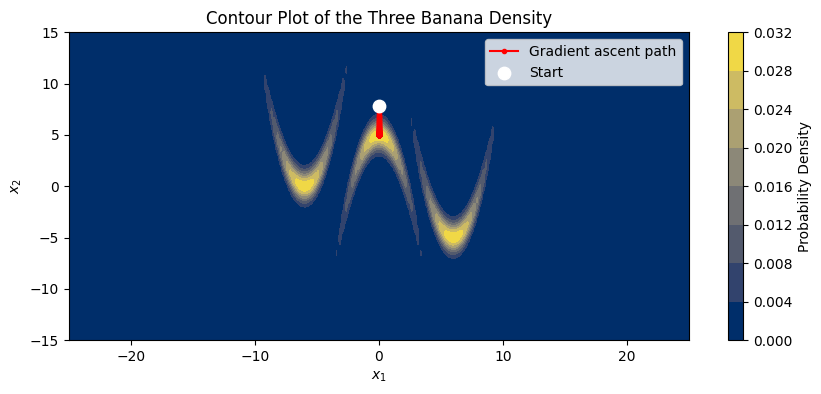

Final points: [0.       5.000105]


In [11]:
visualize_density(log_target_dist)
plt.plot(trajectory[:, 0], trajectory[:, 1],
         'r-o', markersize=3, label='Gradient ascent path')
plt.scatter(trajectory[0, 0], trajectory[0, 1],
            c='white', s=80, zorder=5, label='Start')
plt.legend()
plt.show()

print("Final points:", final_state)

In [12]:
# Based on visulization the gradient ascent trajectory moves neatly toward a peak. That single peak is the banana near (0, 5.2-5.4). That single peak is the mode that's closest to the starting point.
#The gradient ascent trajectory finds one optimum. The gradient ascent trajectory ignores the two bananas. Which mode the gradient ascent trajectory finds depends entirely on the starting point.
#The optimization approach therefore captures none of the multimodal structure. The optimization approach gives no measure of uncertainty.
#The optimization approach yields a single point estimate.
#This is the limitation when compared to Bayesian marginalization. This limitation motivates using a sampling method, like Metropolis-Hastings.

I experimented with the initial condition and step size before settling on final values. Starting at (1, 1) with step size 0.1, the path barely moved since it was already next to a mode. Starting further out at (4, 3) with the same step size, the path wobbled and overshot the ridge, showing the step size was too large. Reducing it to 0.01 from (3, 8) made the path barely move, because (3, 8) is a flat, low-density region where the gradient is almost zero. Finally, starting at (0, 8) with step size 0.05 and 200 iterations, the path descended cleanly onto the peak of the middle banana near (0, 5). This showed the step-size trade-off: too large overshoots, too small is very slow, and flat regions give almost no gradient to follow.

Your answer here

## 1.3 The Metropolis-Hastings algorithm (3 points)
We will now consider marginalization as an alternative to optimization. We consider a Markov Chain Monte Carlo (MCMC) method known as the Metropolis-Hastings algorithm, which like other MCMC algorithms doesn't just find a peak, but travels through the entire probability landscape. The frequency with which it visits a certain state is proportional to that state's probability density. By analyzing the sampler's trajectory, we can understand more about the full distribution, which is one of the main advantages of the marginalization approach.

The Metropolis-Hastings sampler is one of the most fundamental MCMC algorithms. Its core idea is to start from a given position, and propose a random step to a new location (often referred to as the proposal). We then decide whether to accept this new step, based on how the probability at the new location compares to the probability at our current location. If the new spot has a higher probability, we always move there. If it has a lower probability, we *might* move there with a chance proportional to the difference in state likelihood. This element of chance is highly important, as it allows the sampler to explore the entire distribution rather than just climbing the nearest hill to the peak.

In this exercise, you will implement the Metropolis-Hastings algorithm. A code skeleton is provided to help you start, however it is not mandatory to do this and you may also write everything yourself.  

Overall, the Metropolis-Hastings consists of three main parts.

1. First, we will need a proposal distribution. In this exercise we consider a random walk proposal distribution, where the proposed next step is the current position plus random noise drawn from a Gaussian distribution:
\begin{equation}
    \theta^{*} = \theta^{(s)} + \epsilon z^{(s)}, \quad \text{with }  z \sim \mathcal{N}(0, 1)
\end{equation}

2. Calculate the acceptance probability, by comparing the target state probability with the current state probability:
\begin{equation}
    \alpha = \min\left(1, \frac{p(\theta^{*})}{p(\theta^{(s)})}\right)
\end{equation}

3. Accept or reject the proposal based on this probability.

To run your Metropolis-Hastings implementation, choose an initial state, a suitable number of samples to draw, and a suitable number of burn-in steps to prevent the initial condition from influencing the outcome too much.

In [13]:
def proposal_dist(key, state, step_size=1.0):
    r"""
    Random walk proposal distribution, with x_{t+1} = x_{t} + \epsilon N(0, 1), where \epsilon is the step size.

    Params:
        key
        state
        step_size
    """
    z = jr.normal(key, shape=state.shape)
    proposed_state = state + step_size * z  # theta* = theta + step_size * z
    return proposed_state

In [14]:
def metropolis_hastings(log_prob_fn, proposal_fn, initial_state, num_samples, num_burn_in, key):
    """
    Metropolis-Hastings sampler, for a single chain.

    Args:
        log_prob_fn: function that computes the log probability of the target distribution.
        proposal_fn: function that proposes a new state and returns the state and its log probability.
        initial_state: The starting state for the MCMC chain.
        num_samples: Total number of samples.
        num_burn_in: The number of initial samples to discard.
        key: JAX random key.

    Returns:
        (samples, acceptance_rate).
    """

    @jax.jit
    def step(carry, key):

        state, log_prob, accepted_count = carry
        key_proposal, key_accept = jr.split(key)

        # --- Part 1: propose a new state ---
        proposed_state = proposal_fn(key_proposal, state)
        proposed_log_prob = log_prob_fn(proposed_state)

        # --- Part 2: acceptance probability ---
        log_alpha = proposed_log_prob - log_prob

        # --- Part 3: accept or reject ---
        u = jr.uniform(key_accept)
        accept = jnp.log(u) < log_alpha

        next_state = jnp.where(accept, proposed_state, state)          # move if accepted, else stay
        next_log_prob = jnp.where(accept, proposed_log_prob, log_prob) # keep matching log-prob
        new_accepted_count = accepted_count + accept                   # +1 if accepted (True=1)

        return (next_state, next_log_prob, new_accepted_count), next_state


    initial_log_prob = log_prob_fn(initial_state)
    initial_carry = (initial_state, initial_log_prob, 0)


    keys = jr.split(key, num_samples)

    # Run the MCMC loop using lax.scan for performance
    (final_state, final_log_prob, total_accepted), samples = jax.lax.scan(
        step, initial_carry, keys
    )

    # Discard burn-in samples
    samples_after_burn_in = samples[num_burn_in:]

    # Calculate final acceptance rate
    acceptance_rate = total_accepted / num_samples

    return samples_after_burn_in, acceptance_rate

In [15]:
key = jr.PRNGKey(0)
initial_state = jnp.array([0.0, 0.0])
num_samples = 10000
num_burn_in = 1000

samples, acceptance_rate = metropolis_hastings(
    log_target_dist, proposal_dist, initial_state, num_samples, num_burn_in, key
)

print("Number of samples kept:", samples.shape[0])
print("Acceptance rate:", acceptance_rate)

Number of samples kept: 9000
Acceptance rate: 0.4631


In [16]:
#I implemented Metropolis-Hastings with a random walk proposal (current position plus Gaussian noise),
#working in log space so the acceptance ratio becomes a subtraction of log probabilities.
#A better proposal is always accepted, and a worse one is accepted sometimes, which lets the sampler escape a single mode and explore the whole distribution.
#I ran 10000 samples with 1000 burn-in from (0, 0), and with step size 1.0 I got an acceptance rate of about 0.46, showing the sampler explored well without getting stuck.

Your answer here

## 1.4 Visualization of the samples and the true density ( 1.5 points)

a. Create 2 histograms of the samples obtained with your Metropolis-Hastings algorithm, one for $x_1$ and one for $x_2$. Then, overlay the contour plot of the true target density from before with the trajectories of all the samples. How do they compare to the target posterior density function? Comment on the differences between the marginalization and optimization approaches. Why is the former associated with uncertainty quantification?

b. Experiment with and describe how well the Metropolis-Hastings algorithm captures the multi-modality of the banana density under different step sizes for the proposal distribution. Specifically, test step_size values of $\{0.1, 0.5, 1.0\}$ and comment on the sampler's ability to explore all three modes in each case.

c. Analyze how the acceptance rate changes as you vary the step_size. Explain the behavior you observe when the step size is too large, and when it is too small. Based on the theory covered in the lecture slides (week 2), in what range will the optimal acceptance rate be for this specific problem (p=2)? Which of your tested step sizes achieves this acceptance rate?

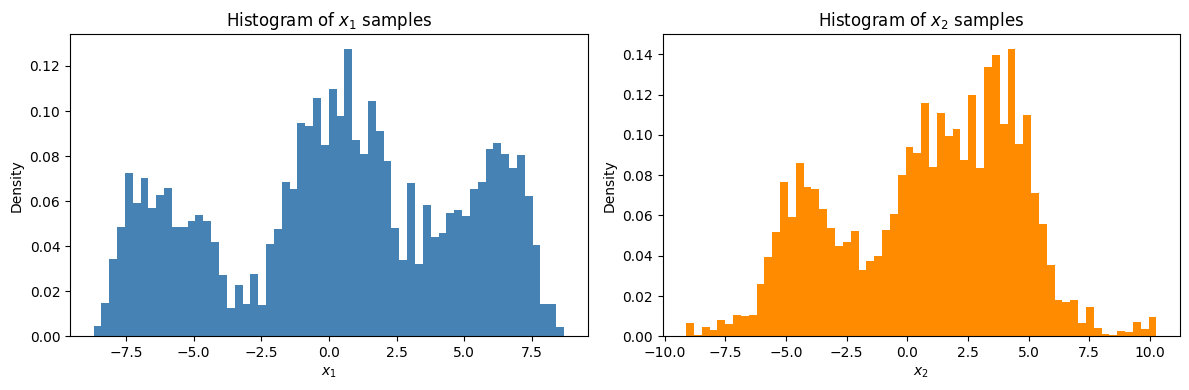

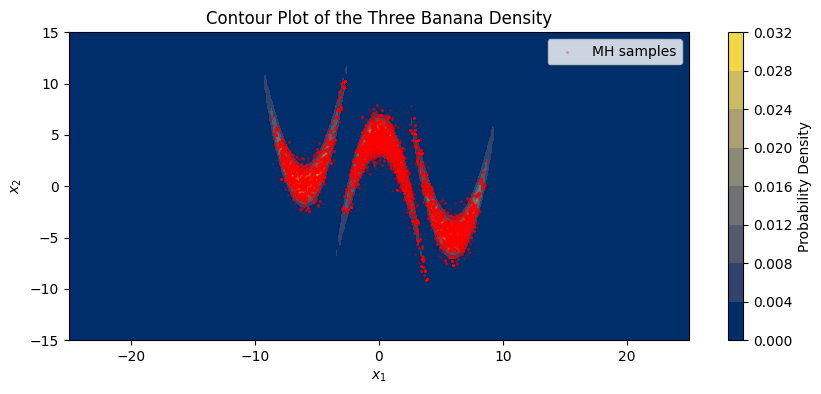

In [34]:
#1.4a]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(samples[:, 0], bins=60, density=True, color='steelblue')
axes[0].set_title("Histogram of $x_1$ samples")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("Density")
axes[1].hist(samples[:, 1], bins=60, density=True, color='darkorange')
axes[1].set_title("Histogram of $x_2$ samples")
axes[1].set_xlabel("$x_2$")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()
visualize_density(log_target_dist)
plt.scatter(samples[:, 0], samples[:, 1],
            c='red', s=2, alpha=0.2, label='MH samples')
plt.legend()
plt.show()

In [35]:
# The samples follow the true density closely: the red scatter covers all three bananas, dense
# at the centers and sparse in the valleys, and the x1 histogram shows three peaks near -6, 0, 6
# matching the three modes. This differs from optimization: gradient ascent stayed in one mode,
# while MH explored the whole distribution and captured all three. Marginalization is tied to
# uncertainty because it returns a full set of samples instead of a single point, so their spread
# tells us how uncertain we are and lets us compute variance or credible intervals, which a single
# optimization point cannot.

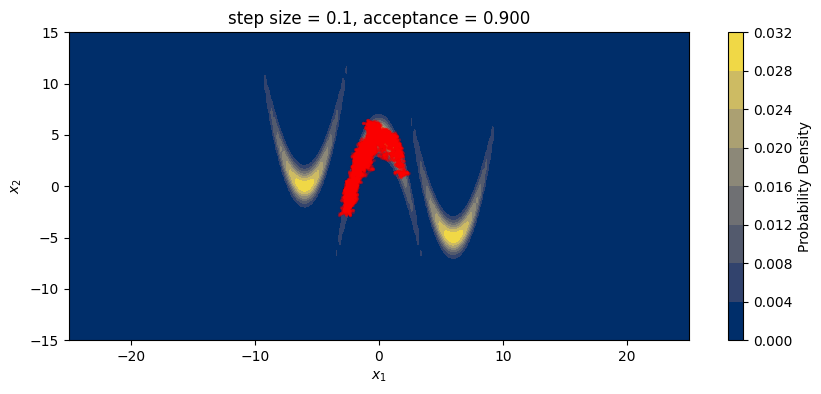

step size 0.1 -> acceptance rate: 0.8999


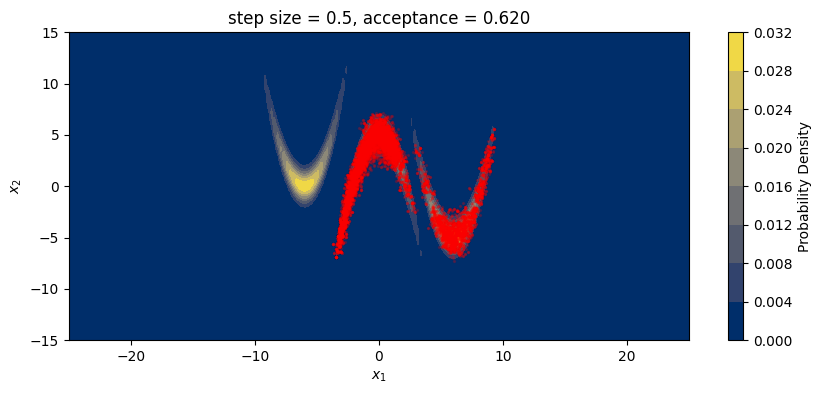

step size 0.5 -> acceptance rate: 0.6197


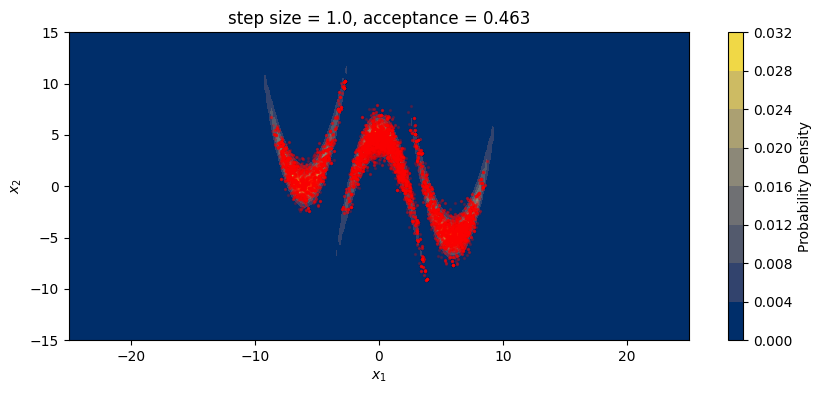

step size 1.0 -> acceptance rate: 0.4631


In [19]:
from functools import partial

step_sizes = [0.1, 0.5, 1.0]
key = jr.PRNGKey(0)
init = jnp.array([0.0, 0.0])

for ss in step_sizes:
    prop = partial(proposal_dist, step_size=ss)
    s, acc = metropolis_hastings(log_target_dist, prop, init, 10000, 1000, key)

    visualize_density(log_target_dist)
    plt.scatter(s[:, 0], s[:, 1], c='red', s=2, alpha=0.2)
    plt.title(f"step size = {ss}, acceptance = {acc:.3f}")
    plt.show()

    print("step size", ss, "-> acceptance rate:", acc)

In [20]:
# With step_size = 0.1 the steps are too small to cross the gaps between bananas, so the sampler stays stuck in one mode despite a high acceptance rate.
# With step_size = 0.5 it explores better and reaches more modes.
# With step_size = 1.0 the steps are large enough to occasionally jump between bananas,so it visits all three modes and captures the multimodality well, at a slightly lower acceptance rate.
# So too small a step size traps the sampler in one mode, and larger steps are needed to explore a multimodal distribution.

In [21]:
#1.4c]
# As the step size increases, the acceptance rate decreases: I observed 0.900 for step_size = 0.1, 0.620 for 0.5, and 0.463 for 1.0.
# When the step size is too small, the proposals land very close to the current point and have almost the same probability, so nearly all of them are accepted (acceptance near 0.9). This looks good but is misleading: the sampler moves in tiny steps, explores very slowly, and cannot cross the low density gaps between the bananas, so it stays stuck in one mode.
# When the step size is too large, the proposals jump far away, often into the low density regions between the modes. These proposals are much less probable than the current state, so most are rejected and the acceptance rate drops toward zero, with the chain repeating the same point.
# From the lecture (week 2), the theoretical optimal acceptance rate for random walk Metropolis-Hastings is about 0.234 in high dimensions, and somewhat higher for low dimensions. For this p = 2 problem the optimal rate is roughly in the 0.234 to 0.4 range. Among my tested step sizes, step_size = 1.0 with an acceptance rate of 0.463 is the closest to this optimal range, and it is also the only one that managed to explore all three modes.

## 1.5 A more challenging target density (1 points)


Triple banana density, with more distance between the Gaussian components. Now consider: $\mu_k = (-10, 0, 10)^{\top}$. Repeat your analysis of before, and consider the coverage of the sampler under various step sizes (using the acceptance ratio as a useful tool).


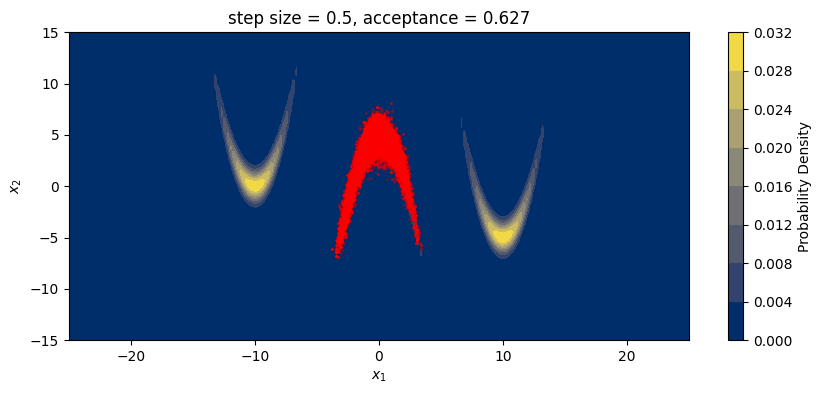

step size 0.5 :acceptance rate: 0.6275


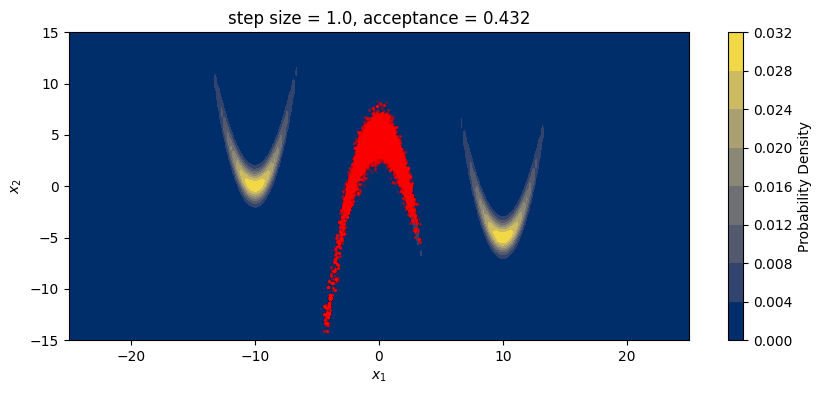

step size 1.0 :acceptance rate: 0.4322


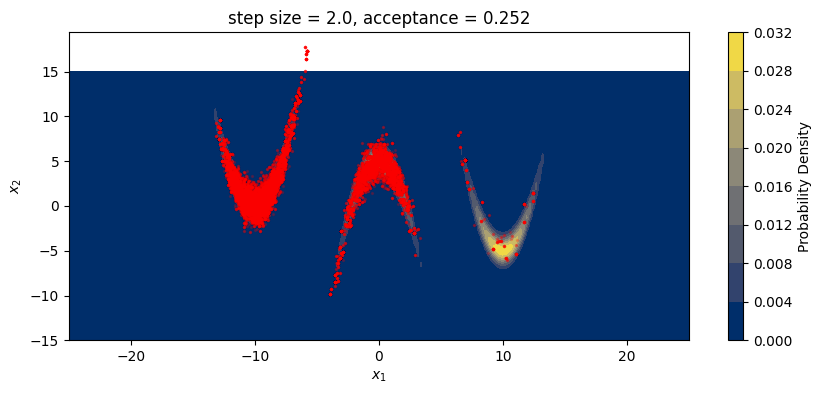

step size 2.0 :acceptance rate: 0.25235


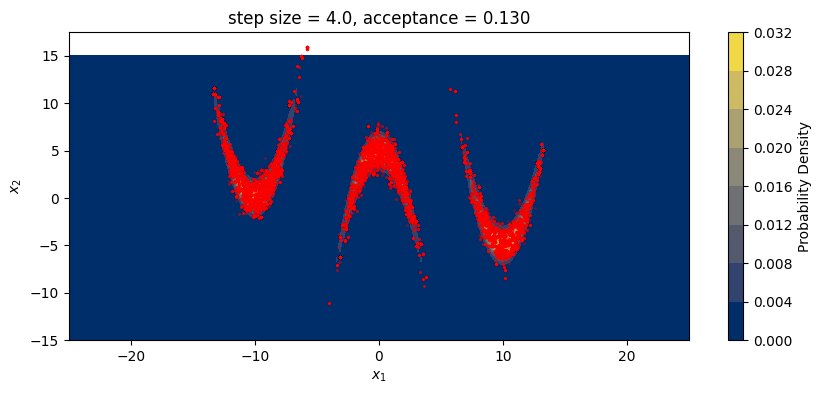

step size 4.0 :acceptance rate: 0.1297


In [28]:
# 1.5: triple banana with modes moved further apart, mu_k = (-10, 0, 10)
def log_target_dist_far(x):
    mu_k = jnp.array([-10.0, 0.0, 10.0])
    cov = jnp.array([[jnp.sqrt(8.0), 0.0], [0.0, 1.0]])
    b = jnp.array([1., -1., 1.])
    c = jnp.array([0.0, 5.0, -5.0])
    means = jnp.stack([mu_k, c + b * (x[0] - mu_k)**2], axis=-1)
    return logsumexp(multivariate_normal.logpdf(x, mean=means, cov=cov)) - jnp.log(3)

init = jnp.array([0.0, 0.0])

for ss in [0.5, 1.0, 2.0, 4.0]:
    prop = partial(proposal_dist, step_size=ss)
    s, acc = metropolis_hastings(log_target_dist_far, prop, init, 20000, 2000, jr.PRNGKey(0))

    visualize_density(log_target_dist_far)
    plt.scatter(s[:, 0], s[:, 1], c='red', s=2, alpha=0.2)
    plt.title(f"step size = {ss}, acceptance = {acc:.3f}")
    plt.show()
    print("step size", ss, ":acceptance rate:", acc)

## 1.6: The most ambitious crossover event in history? (3 points)
### Using gradients in our MCMC algorithms with MALA (Metropolis-adjusted Langevin algorithm)
So far we've treated optimization (using gradient ascent) and sampling (using Metropolis-Hastings), however it is possible to leverage gradient information in MCMC. In the Metropolis-Hastings algorithm, the random walk proposal is simple but in a way "blind": the direction in the proposal distribution is generated by a proposal distribution that does not consider the particular probability landscape at hand. In practice, this leads to a low acceptance rate, leading to inefficient computation. Gradient information can be used to further guide the process, while still retaining the desirable properites of marginalization.

The Metropolis-Adjusted Langevin Algorithm (MALA) algorithm uses the gradient of the log probability (much like the gradient we used in the optimization exercise) to inform the proposals. A major consequence of this is that the proposal distribution loses its symmetry, which requires a correction term in the acceptance ratio (hence, the 'adjusted' in the name).  The MALA proposals follow Langevin dynamics:

\begin{equation}
    \theta^{(s+1)}=\theta^{(s)}+\epsilon \nabla_{\theta} \text{log } p(\theta^{(s)})+\sqrt{2 \epsilon} ​z^{(s)}
\end{equation}
with $z \sim \mathcal{N}(0,I_p​)$. With $\theta^*$ as new proposed state sampled from the proposal distribution (see lecture slides), the new acceptance ratio is defined as:
\begin{equation}
    \alpha = \min\left(1, \frac{p(\theta^{*}) q(\theta^{(s)} \mid \theta^{*})}{p(\theta^{(s)}) q(\theta^{*} \mid \theta^{(s)})}\right)
\end{equation}
Unfortunately, since we lost the symmetry of the proposal distribution, the ratio $\dfrac{q(\theta^{(s)} \mid \theta^{*})}{ q(\theta^{*} \mid \theta^{(s)})}$ is not trivially 1 anymore, so we have to compute this.
  
Write an implementation of the MALA algorithm. You may, and are recommended to, use your previous code of the gradient function (exercise 1.2) as well as the code of the Metropolis-Hastings algorithm to get started.

a. Evaluate the algorithm on the initial banana density. Is MALA able to cover all three modes well?

b. Consider the more challenging density: what happens to the acceptance rate when the means are placed further away from each other?

In [29]:
def mala_proposal_fn(key, state, log_prob_fn, step_size):
    """
    Performs a single MALA step, proposing a new state and calculating
    the log probabilities of the forward and reverse proposals.

    Args:
        key
        state
        log_prob_fn
        step_size

    Returns:
        (proposed_state, log_prob_forward, log_prob_backward)
    """

    grad_fn = jax.grad(log_prob_fn)

    # 1. Calculate the gradient of the current state and take a step in the direction of the gradient (like in exercise 1.2)
    drift_forward = state + step_size * grad_fn(state)

    # 2. Propose a new state with a random walk, and get the forward proposal theta*
    z = jr.normal(key, shape=state.shape)
    proposed_state = drift_forward + jnp.sqrt(2 * step_size) * z

    # 3. Calculate the log probability of the forward proposal q(theta* | theta^s)
    # Gaussian centred at drift_forward with variance 2*step_size; constants cancel in the ratio
    log_prob_proposed_state = -jnp.sum((proposed_state - drift_forward)**2) / (4 * step_size)

    # 4. Calculate the log probability of the backward proposal q(theta^s | theta*)
    # drift is now computed at the proposed state
    drift_backward = proposed_state + step_size * grad_fn(proposed_state)
    log_prob_backward = -jnp.sum((state - drift_backward)**2) / (4 * step_size)

    return proposed_state, log_prob_proposed_state, log_prob_backward

In [30]:
def mala(log_prob_fn, mala_proposal_fn, initial_state, num_samples, num_burn_in, step_size, key):
    """
    Metropolis-Adjusted Langevin Algorithm (MALA), for a single chain.

    Args:
        log_prob_fn: function that computes the log probability of the target distribution.
        mala_proposal_fn: function that proposes a new state and returns the state and its log probability according to MALA.
        initial_state: The starting state for the MCMC chain.
        num_samples: Total number of samples.
        num_burn_in: The number of initial samples to discard.
        key: JAX random key.

    Returns:
        (samples, acceptance_rate).
    """

    @jax.jit
    def step(carry, key):
        """Performs a single step of the MALA MCMC sampler."""
        state, log_prob, accepted_count = carry
        key_proposal, key_accept = jr.split(key)

        ### Your code here
        proposed_state, log_fwd, log_bwd = mala_proposal_fn(key_proposal, state, log_prob_fn, step_size)
        proposed_log_prob = log_prob_fn(proposed_state)

        # acceptance ratio in log space, with the asymmetry correction (add backward, subtract forward)
        log_alpha = (proposed_log_prob + log_bwd) - (log_prob + log_fwd)
        accept = jnp.log(jr.uniform(key_accept)) < log_alpha

        next_state = jnp.where(accept, proposed_state, state)
        next_log_prob = jnp.where(accept, proposed_log_prob, log_prob)
        new_accepted_count = accepted_count + accept

        return (next_state, next_log_prob, new_accepted_count), next_state

    # Initialize
    initial_log_prob = log_prob_fn(initial_state)
    initial_carry = (initial_state, initial_log_prob, 0)

    # Generate keys for each step
    keys = jr.split(key, num_samples)

    # Run the MCMC loop using lax.scan for performance
    (final_state, final_log_prob, total_accepted), samples = jax.lax.scan(
        step, initial_carry, keys
    )

    # Discard burn-in samples
    samples_after_burn_in = samples[num_burn_in:]

    # Calculate acceptance rate
    acceptance_rate = total_accepted / num_samples

    return samples_after_burn_in, acceptance_rate

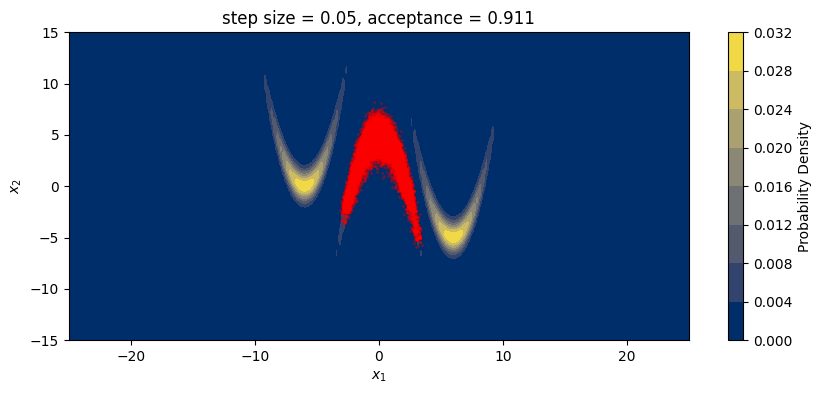

step size 0.05 -> acceptance rate: 0.91135


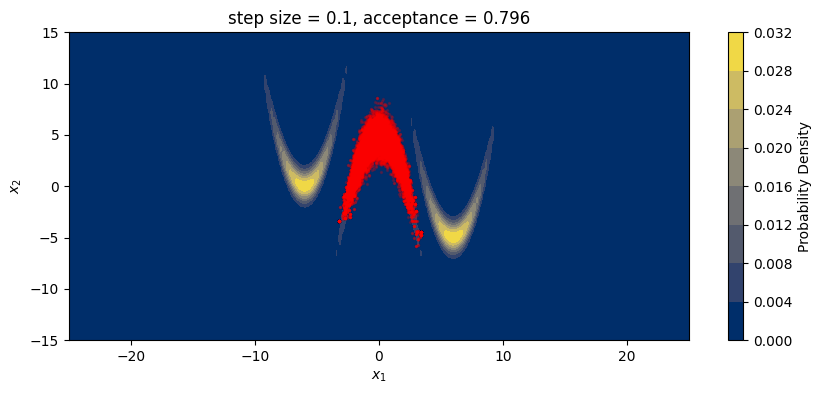

step size 0.1 -> acceptance rate: 0.79635


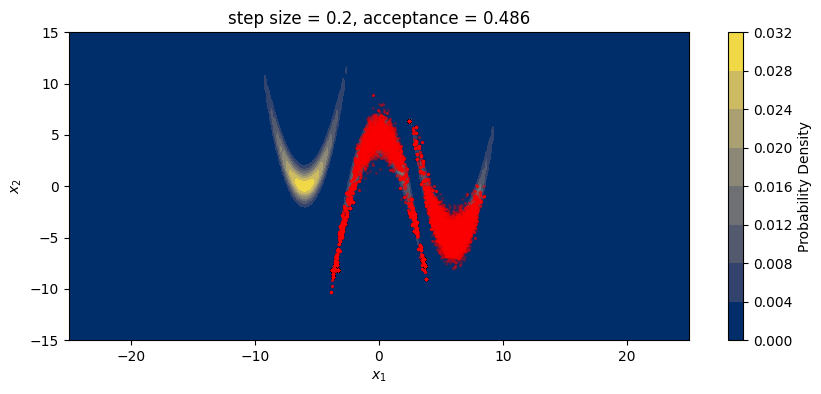

step size 0.2 -> acceptance rate: 0.48575


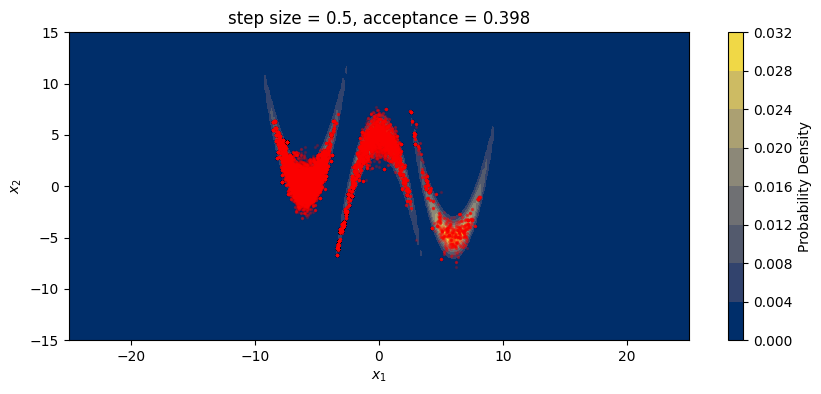

step size 0.5 -> acceptance rate: 0.39765


In [31]:
# 1.6a: MALA on the original banana density, mu_k = (-6, 0, 6)
init = jnp.array([0.0, 0.0])

for ss in [0.05, 0.1, 0.2, 0.5]:
    s, acc = mala(log_target_dist, mala_proposal_fn, init, 20000, 2000, ss, jr.PRNGKey(0))
    visualize_density(log_target_dist)
    plt.scatter(s[:, 0], s[:, 1], c='red', s=2, alpha=0.2)
    plt.title(f"step size = {ss}, acceptance = {acc:.3f}")
    plt.show()
    print("step size", ss, "-> acceptance rate:", acc)

In [32]:
# 1.6a] MALA steps uphill along the gradient and adds Gaussian noise, so proposals aim at
# high-density regions instead of being blind. With small steps (ss=0.05, 0.1) acceptance is
# high (~0.9, 0.8) but the chain is stuck in the central mode. At ss=0.2 (acc ~0.49) it finally
# crosses the valleys and covers all three modes. So yes, MALA covers all three, but only at a
# well-tuned step size, and the split across modes is still a bit uneven.

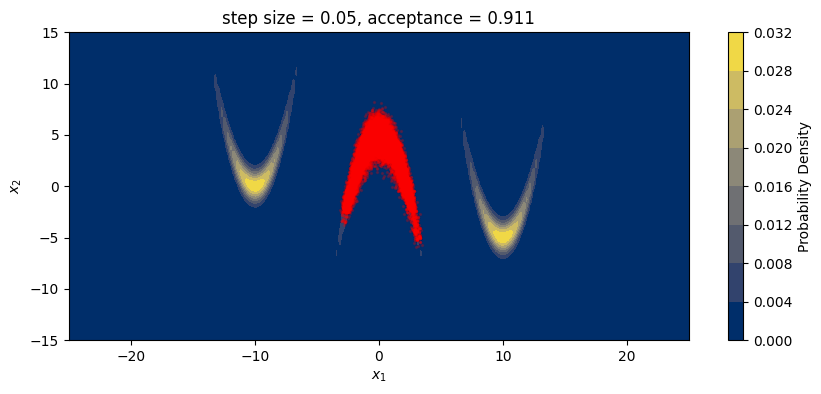

step size 0.05 -> acceptance rate: 0.91135


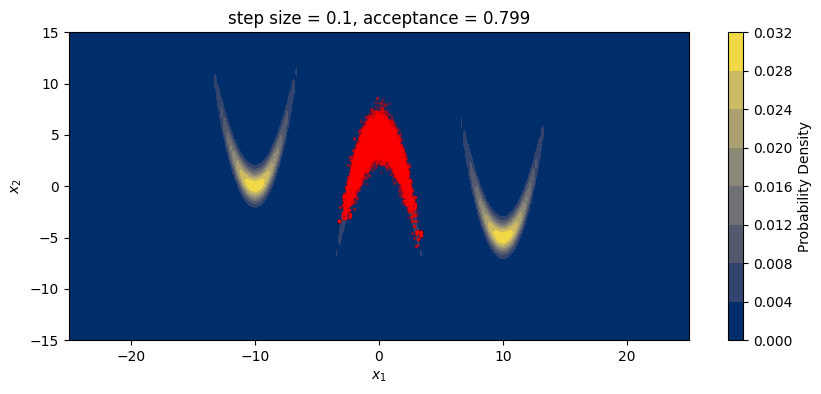

step size 0.1 -> acceptance rate: 0.79915


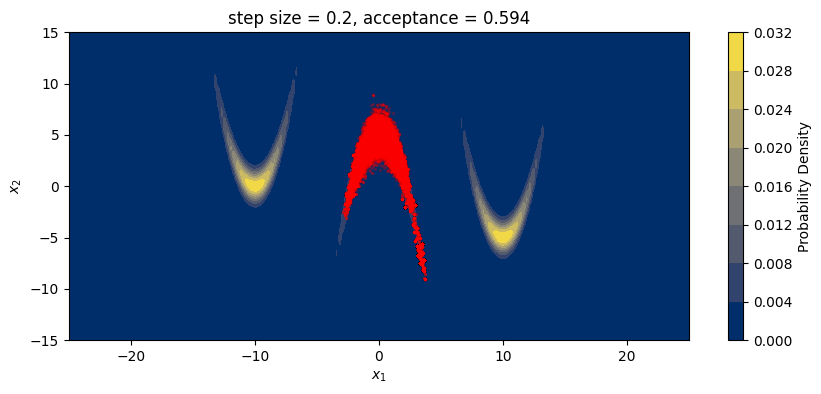

step size 0.2 -> acceptance rate: 0.594


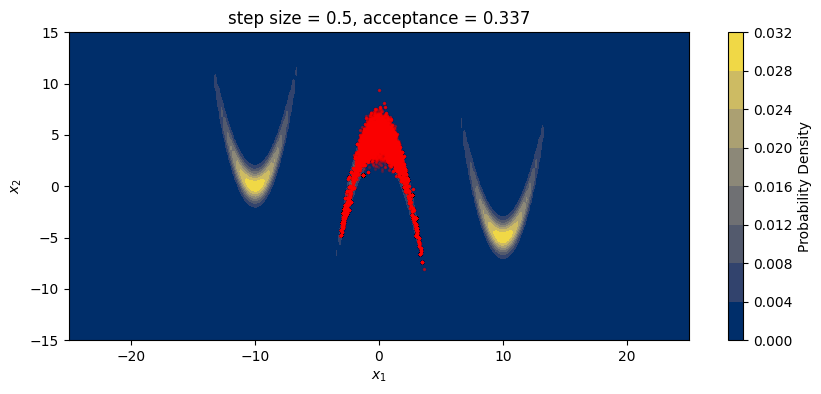

step size 0.5 -> acceptance rate: 0.33665


In [33]:
# 1.6b: MALA on the harder density, means further apart mu_k = (-10, 0, 10)
init = jnp.array([0.0, 0.0])

for ss in [0.05, 0.1, 0.2, 0.5]:
    s, acc = mala(log_target_dist_far, mala_proposal_fn, init, 20000, 2000, ss, jr.PRNGKey(0))
    visualize_density(log_target_dist_far)
    plt.scatter(s[:, 0], s[:, 1], c='red', s=2, alpha=0.2)
    plt.title(f"step size = {ss}, acceptance = {acc:.3f}")
    plt.show()
    print("step size", ss, "-> acceptance rate:", acc)

In [ ]:
# 1.6b] Acceptance still drops as step size grows (~0.91, 0.80, 0.59, 0.34), but now the chain
# stays stuck in the central mode at every step size. In the wide valley the gradient points
# back toward the mode just left, so the drift resists the long jump to a distant mode: the
# informed proposal helps locally but hurts global exploration. This motivates HMC/NUTS.